# **Data** **Exploration and Visualization of the Collected Data from PiCar Simulator**
## In this section, we will

1. **Load and inspect the dataset** collected in **Lab 3**.
2. **Visualize the data** to assess its quality and diversity.
3. **Analyze the steering angle distribution** to determine if the dataset is balanced.

In [1]:
# Import libraries
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import random
import zipfile
from google.colab import drive



In [2]:
# Mount Google Drive to access dataset
drive.mount("/content/gdrive", force_remount=True)

# Define dataset file name and directory
data_file = "data_9"  # Ensure this matches the collected dataset name
zip_path = "/content/gdrive/MyDrive/data_9.zip"



Mounted at /content/gdrive


In [3]:
# Extract dataset
if not os.path.exists(f"/content/{data_file}"):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/")
    print(f"Extracted {data_file} dataset.")

# Set paths for training and testing data
data_dir = f'/content/{data_file}/'
train_dir = data_dir + 'train/'
test_dir = data_dir + 'test/'



Extracted data_9 dataset.


In [4]:
# Function to load data (image paths and steering angles)
def load_data(directory):
    """
    Loads image file paths and extracts steering angles from filenames.
    """
    image_paths = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(".png")]
    image_paths.sort(key=lambda x: int(x.split('/')[-1][:-4].split('_')[0]))  # Sort by timestamp

    # Extract steering angles from filenames
    steering_angles = [float(f.split('/')[-1][:-4].split('_')[-1].replace('-', '.')) for f in image_paths]

    return image_paths, steering_angles

# Load training and testing data
train_img, train_steer = load_data(train_dir)
test_img, test_steer = load_data(test_dir)

print(f"Loaded {len(train_img)} training images and {len(test_img)} test images.")



Loaded 10000 training images and 3000 test images.


**Visualizations of Sample Images Collected from PiCar Simulator**: Visualizing samples ensures that the dataset is high-quality, diverse, and ready for training a reliable machine learning model.

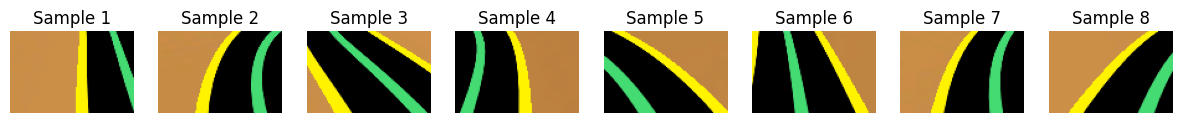

In [5]:
# Function to display sample images
def display_sample_images(image_paths, num_samples=8):
    """
    Displays random sample images from the dataset.
    """
    sample_paths = random.sample(image_paths, min(num_samples, len(image_paths)))

    fig, axs = plt.subplots(1, len(sample_paths), figsize=(15, 5))
    for i, path in enumerate(sample_paths):
        img = cv.imread(path)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Convert to RGB
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"Sample {i+1}")

    plt.show()

# Display random sample images
display_sample_images(train_img)

**Visualizations of Steering Angle Distribution:** Visualizing the steering angle distribution helps to ensure that the dataset is balanced and diverse, which is essential for building a reliable and effective driving model.

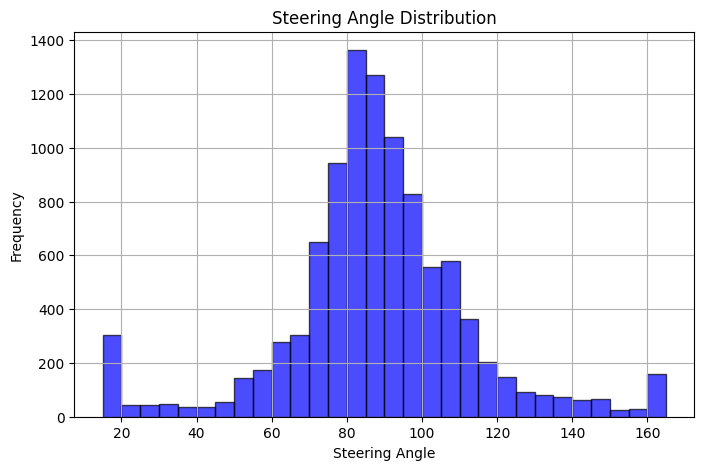

In [6]:
# Function to plot steering angle distribution
def plot_steering_angle_distribution(steering_angles):
    """
    Plots a histogram of steering angles to check data distribution.
    """
    plt.figure(figsize=(8, 5))
    plt.hist(steering_angles, bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel("Steering Angle")
    plt.ylabel("Frequency")
    plt.title("Steering Angle Distribution")
    plt.grid(True)
    plt.show()

# Plot steering angle distribution
plot_steering_angle_distribution(train_steer)

In [ ]:
print("Data Exploration and Visualization Completed.")

Data Exploration and Visualization Completed.
